In [2]:
# Cell 1 — imports
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys

import os
os.makedirs('../results', exist_ok=True)

sys.path.append('..')

# Dataset is already QC'd and filtered, so we can skip those steps. Start with normalization and clustering.
from src.preprocess import run_normalization, save_checkpoint, load_checkpoint
from src.cluster import run_clustering_pipeline
from src.visualize import plot_umap
from src.annotate import score_gene_set, export_marker_table, find_marker_genes

sc.settings.verbosity = 3
sc.settings.figdir = '../results/'

In [3]:
# Cell 2 - Load Data
adata = sc.read_h5ad('../data/SEAAD_microglia.h5ad')
print("Microglia dataset loaded") 
print(adata)

metadata = pd.read_excel('../data/SEAAD_donor_metadata.xlsx')
print("Clinical columns:")
print(metadata.columns.tolist())

neuropath = pd.read_csv('../data/SEAAD_neuropathology.csv')
print("Neuropathology columns:")
print(neuropath.columns.tolist())

print("\n--- donor ID column in adata.obs ---")
donor_cols = [c for c in adata.obs.columns if any(x in c.lower() for x in ['donor', 'external', 'specimen'])]
print(donor_cols)
print(adata.obs[donor_cols].head(5))

Microglia dataset loaded
AnnData object with n_obs × n_vars = 240651 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Inter

In [4]:
# Cell 3 - Inspecting Clinical Variables

# Key clinical variables not found are commented out
key_clinical = [
    'Cognitive Status',
    'Braak', 
    'CERAD score',
    'Overall AD neuropathological Change',
    'Thal', 
    'APOE Genotype',
    'Severely Affected Donor',
    'Sex',
    'Age at Death'
]

for col in key_clinical:
    if col in adata.obs.columns:
        print(f"\n{col}:")
        print(adata.obs[col].value_counts())
    else:
        print(f"\n{col}: NOT FOUND")


Cognitive Status:
Cognitive Status
No dementia    121506
Dementia       119145
Name: count, dtype: int64

Braak:
Braak
Braak V      90805
Braak IV     59138
Braak VI     48516
Braak III    17893
Braak II     17536
Braak 0       6763
Name: count, dtype: int64

CERAD score:
CERAD score
Moderate    84540
Frequent    82094
Absent      45988
Sparse      28029
Name: count, dtype: int64

Overall AD neuropathological Change:
Overall AD neuropathological Change
High            123712
Intermediate     50349
Low              43458
Not AD           23132
Name: count, dtype: int64

Thal:
Thal
Thal 4    85565
Thal 5    59597
Thal 3    29986
Thal 2    23599
Thal 0    23132
Thal 1    18772
Name: count, dtype: int64

APOE Genotype:
APOE Genotype
3/3    143325
3/4     47881
2/3     28330
4/4     16741
2/4      3666
2/2       708
Name: count, dtype: int64

Severely Affected Donor:
Severely Affected Donor
N    216446
Y     24205
Name: count, dtype: int64

Sex:
Sex
Female    138684
Male      101967
Name: 

In [28]:
# Cell 4 - Inspect Existing Cell Type Annotations

print("Subclass labels:")
print(adata.obs['Subclass'].value_counts())

print("\nSupertype labels:")
print(adata.obs['Supertype'].value_counts())

print("\nClass labels:")
print(adata.obs['Class'].value_counts())

Subclass labels:
Subclass
Microglia-PVM    240651
Name: count, dtype: int64

Supertype labels:
Supertype
Micro-PVM_2            141248
Micro-PVM_2_3-SEAAD     53815
Micro-PVM_3-SEAAD       29805
Micro-PVM_1              7909
Lymphocyte               4607
Micro-PVM_4-SEAAD        1767
Micro-PVM_2_1-SEAAD      1458
Monocyte                   42
Name: count, dtype: int64

Class labels:
Class
Non-neuronal and Non-neural    240651
Name: count, dtype: int64


In [17]:
# Cell 5 - Check normalization status of adata.X and layers['UMIs']

# find genes with nonzero expression and sample those
nonzero_genes = np.where(np.array(adata.X.sum(axis=0)).flatten() > 0)[0][:5]

print("Normalized values (adata.X) for expressed genes:")
print(adata.X[:3, nonzero_genes].toarray())

print("\nRaw UMI counts for same genes:")
print(adata.layers['UMIs'][:3, nonzero_genes].toarray())

print("\nuns keys (log1p key = already normalized):")
print(list(adata.uns.keys()))

# diagnostic 1: check matrix stats
x_dense = adata.X[:100, :100].toarray()
print("Diagnostic 1")
print("Min:", x_dense.min())
print("Max:", x_dense.max())
print("Nonzero count:", np.count_nonzero(x_dense))
print("Total elements:", x_dense.size)

# d2: check matrix type and shape
print("Diagnostic 2")
print(type(adata.X))
print(adata.X.dtype)
print("Shape (cells x genes):", adata.shape)

# d3: check known microglial markers directly 

marker_genes = ['TREM2', 'P2RY12', 'CX3CR1', 'CSF1R', 'TMEM119']
print("Diagnostic 3")
for gene in marker_genes:
    if gene in adata.var_names:
        idx = list(adata.var_names).index(gene)
        vals = adata.X[:5, idx].toarray().flatten()
        print(f"{gene}: {vals}")
    else:
        print(f"{gene}: NOT FOUND in var_names")

#d4: check var_names
print("Diagnostic 4")
print("First 20 gene names:")
print(adata.var_names[:20].tolist())

print("\nTotal genes:", len(adata.var_names))

# Confirmed log-normalized. log1p floats + log1p in uns

Normalized values (adata.X) for expressed genes:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Raw UMI counts for same genes:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

uns keys (log1p key = already normalized):
['Subclass_colors', 'Supertype_colors', 'log1p', 'neighbors', 'umap', 'Cognitive Status_colors', 'Braak_colors', 'Severely Affected Donor_colors']
Diagnostic 1
Min: 0.0
Max: 5.067644413153379
Nonzero count: 574
Total elements: 10000
Diagnostic 2
<class 'scipy.sparse._csr.csr_matrix'>
float64
Shape (cells x genes): (240651, 36601)
Diagnostic 3
TREM2: [2.12983138 0.         0.         0.         0.        ]
P2RY12: [3.42275637 4.31034787 4.34477318 3.95826411 4.84000919]
CX3CR1: [3.96829248 4.71132664 4.34477318 0.         0.        ]
CSF1R: [4.41337907 4.99675797 4.06140659 4.28926534 4.43848978]
TMEM119: [0.         0.         0.         0.         3.08702313]
Diagnostic 4
First 20 gene names:
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3'

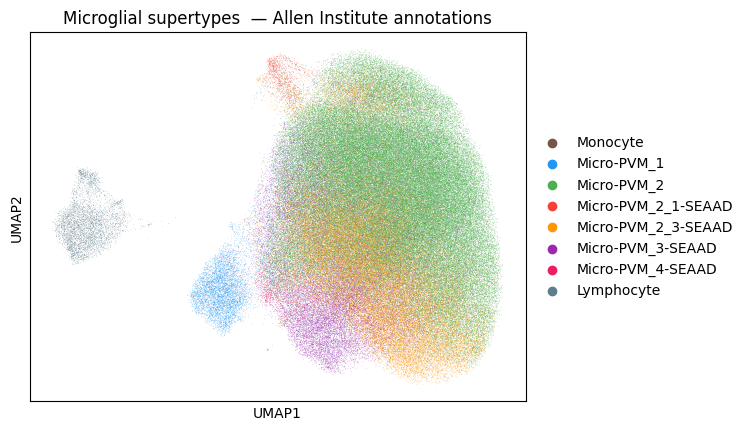

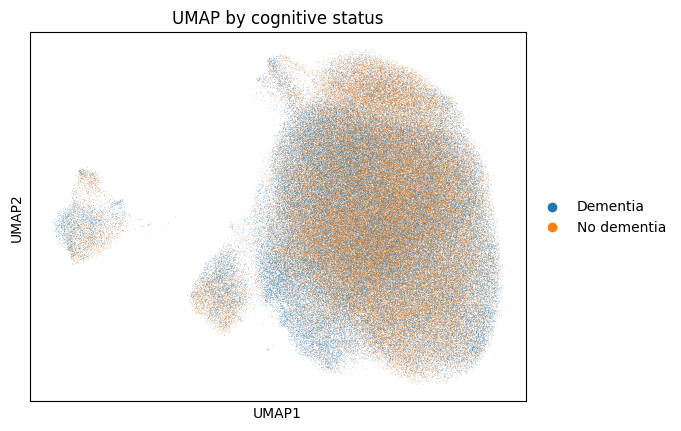

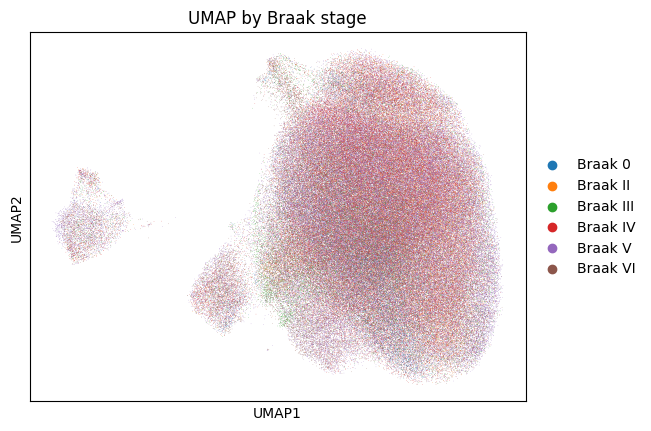

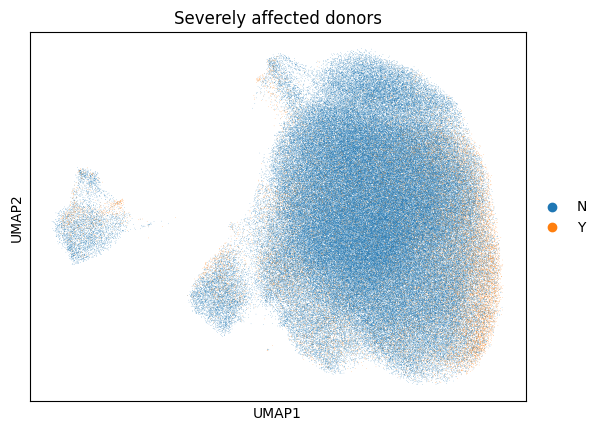

In [16]:
# Cell 6 - Visualize existing UMAP embeddings colored by clinical variables

# fix supertype colors
supertypes = adata.obs['Supertype'].cat.categories.tolist()
color_map = {
    'Micro-PVM_1':         '#2196F3',  # blue
    'Micro-PVM_2':         '#4CAF50',  # green
    'Micro-PVM_2_1-SEAAD': '#F44336',  # red
    'Micro-PVM_2_3-SEAAD': '#FF9800',  # orange
    'Micro-PVM_3-SEAAD':   '#9C27B0',  # purple
    'Micro-PVM_4-SEAAD':   '#E91E63',  # pink
    'Monocyte':            '#795548',  # brown
    'Lymphocyte':          '#607D8B',  # grey
}
adata.uns['Supertype_colors'] = [color_map.get(s, '#333333') for s in supertypes]

# color by cell supertype — Allen Institute annotations
sc.pl.umap(adata, color='Supertype',
           title='Microglial supertypes  — Allen Institute annotations',
           save = '_supertype.png')


# color by cognitive status — disease grouping
sc.pl.umap(adata, color='Cognitive Status',
           title='UMAP by cognitive status',
           save = '_cognitive_status.png')

# color by Braak stage — continuous disease severity
sc.pl.umap(adata, color='Braak',
           title='UMAP by Braak stage',
           color_map='RdYlBu_r',
            save = '_braak_stage.png')

# color by severely affected donor flag
sc.pl.umap(adata, color='Severely Affected Donor',
           title='Severely affected donors',
           save = '_severely_affected_donor.png')

In [ ]:
# Cell 7 - Merge Neuropathology and Clinical Metadata

# Step 1: only keep meta columns that aren't already in adata.obs
meta_cols = [
    'Donor ID', 'Braak', 'CERAD score', 'Thal',
    'Overall AD neuropathological Change', 'APOE Genotype',
    'Age at Death', 'Sex', 'PMI', 'Last MMSE Score', 'LATE'
]

# filter to only new columns
new_meta_cols = ['Donor ID'] + [c for c in meta_cols[1:] 
                                 if c not in adata.obs.columns]
print("Meta cols to merge:", new_meta_cols)

# Step 2: neuropath columns
neuropath_cols = [
    'Donor ID',
    'percent Iba1 positive area_Grey matter',
    'number of activated Iba1 positive cells_Grey matter',
    'number of inactivated Iba1 positive cells_Grey matter',
    'number of Iba1 positive cells per area_Grey matter',
    'average Iba1 positive process length per cell_Grey matter',
    'percent AT8 positive area_Grey matter',
    'number of AT8 positive cells per area_Grey matter',
    'percent 6e10 positive area_Grey matter',
    'number of NeuN positive cells per area_Grey matter',
    'percent pTDP43 positive area_Grey matter',
    'ripa abeta42_Grey matter',
    'ripa pTau_Grey matter',
]

new_neuropath_cols = ['Donor ID'] + [c for c in neuropath_cols[1:] 
                                      if c not in adata.obs.columns]
print("Neuropath cols to merge:", new_neuropath_cols)

# Step 3: merge only new columns
if len(new_meta_cols) > 1:
    meta_slim = metadata[new_meta_cols].set_index('Donor ID')
    adata.obs = adata.obs.join(meta_slim, on='Donor ID')

neuropath_slim = neuropath[new_neuropath_cols].set_index('Donor ID')
adata.obs = adata.obs.join(neuropath_slim, on='Donor ID')

# Step 4: verify
print("\nSample merged values:")
check_cols = ['Donor ID', 'Braak', 'CERAD score', 
              'percent Iba1 positive area_Grey matter']
# only print cols that exist
check_cols = [c for c in check_cols if c in adata.obs.columns]
print(adata.obs[check_cols].head(5))

print("\nMissing values:")
print(adata.obs[check_cols].isnull().sum())

Meta cols to merge: ['Donor ID']
Neuropath cols to merge: ['Donor ID', 'percent Iba1 positive area_Grey matter', 'number of activated Iba1 positive cells_Grey matter', 'number of inactivated Iba1 positive cells_Grey matter', 'number of Iba1 positive cells per area_Grey matter', 'average Iba1 positive process length per cell_Grey matter', 'percent AT8 positive area_Grey matter', 'number of AT8 positive cells per area_Grey matter', 'percent 6e10 positive area_Grey matter', 'number of NeuN positive cells per area_Grey matter', 'percent pTDP43 positive area_Grey matter', 'ripa abeta42_Grey matter', 'ripa pTau_Grey matter']

Sample merged values:
                                                  Donor ID    Braak  \
exp_component_name                                                    
AAAGAACTCCAACACA-L8HX_230330_23_E03-1266294882  H21.33.036  Braak V   
AACAACCTCTATTTCG-L8HX_230330_23_E03-1266294882  H21.33.036  Braak V   
AACCATGCACGGGTAA-L8HX_230330_23_E03-1266294882  H21.33.036  Braak 

In [23]:
# Cell 8 – Gene Set Scoring

# DAM signature – Haage et. al 2024; inclusion of both DAM1 & DAM2 genes
dam_genes = ['APOE', 'H2-D1', 'B2M', 'FTH1', 'CSTB',
             'LYZ2', 'CTSB', 'TYROBP', 'TIMP2', 'CTSD',
             'ANK', 'CD9', 'CD63', 'SERPINE2', 'SPP1', 'CADM1',
             'CD68', 'CTSZ', 'AXL', 'CLEC7A', 'CTSA', 'CD52',
             'CSF1', 'CCL6', 'LPL', 'CTSL', 'CST7', 'ITGAX', 'GUSB', 'HIF1A']

# Homeostatic signature – Gerrits et al. 2020
homeostatic_genes = ['Sall1', 'Hexb', 'Fcrls', 'Gpr43',
                     'Cx3cr1', 'Tmem119', 'Trem2', 'P2ry12',
                     'Mertk', 'Pros1', 'Siglech']

# Case-insensitive filtering and remapping to exact casing in adata
var_names_upper = [g.upper() for g in adata.var_names]
upper_to_actual = {g.upper(): g for g in adata.var_names}

dam_genes_filtered = [upper_to_actual[g.upper()] for g in dam_genes if g.upper() in var_names_upper]
homeostatic_genes_filtered = [upper_to_actual[g.upper()] for g in homeostatic_genes if g.upper() in var_names_upper]

print("DAM genes found:", dam_genes_filtered)
print("Homeostatic genes found:", homeostatic_genes_filtered)

# score each cell
sc.tl.score_genes(adata, dam_genes_filtered, score_name='DAM_score')
sc.tl.score_genes(adata, homeostatic_genes_filtered, score_name='Homeostatic_score')

# visualize on UMAP
#sc.pl.umap(adata, color=['DAM_score', 'Homeostatic_score'],
#           color_map='RdYlBu_r', show=False)
# plt.savefig('../results/umap_gene_scores.png',
#             dpi=300, bbox_inches='tight', facecolor='white')
# plt.show()
# plt.close()

DAM genes found: ['APOE', 'B2M', 'FTH1', 'CSTB', 'CTSB', 'TYROBP', 'TIMP2', 'CTSD', 'CD9', 'CD63', 'SERPINE2', 'SPP1', 'CADM1', 'CD68', 'CTSZ', 'AXL', 'CLEC7A', 'CTSA', 'CD52', 'CSF1', 'LPL', 'CTSL', 'CST7', 'ITGAX', 'GUSB', 'HIF1A']
Homeostatic genes found: ['SALL1', 'HEXB', 'CX3CR1', 'TMEM119', 'TREM2', 'P2RY12', 'MERTK', 'PROS1']
computing score 'DAM_score'
    finished: added
    'DAM_score', score of gene set (adata.obs).
    499 total control genes are used. (0:00:14)
computing score 'Homeostatic_score'
    finished: added
    'Homeostatic_score', score of gene set (adata.obs).
    149 total control genes are used. (0:00:13)


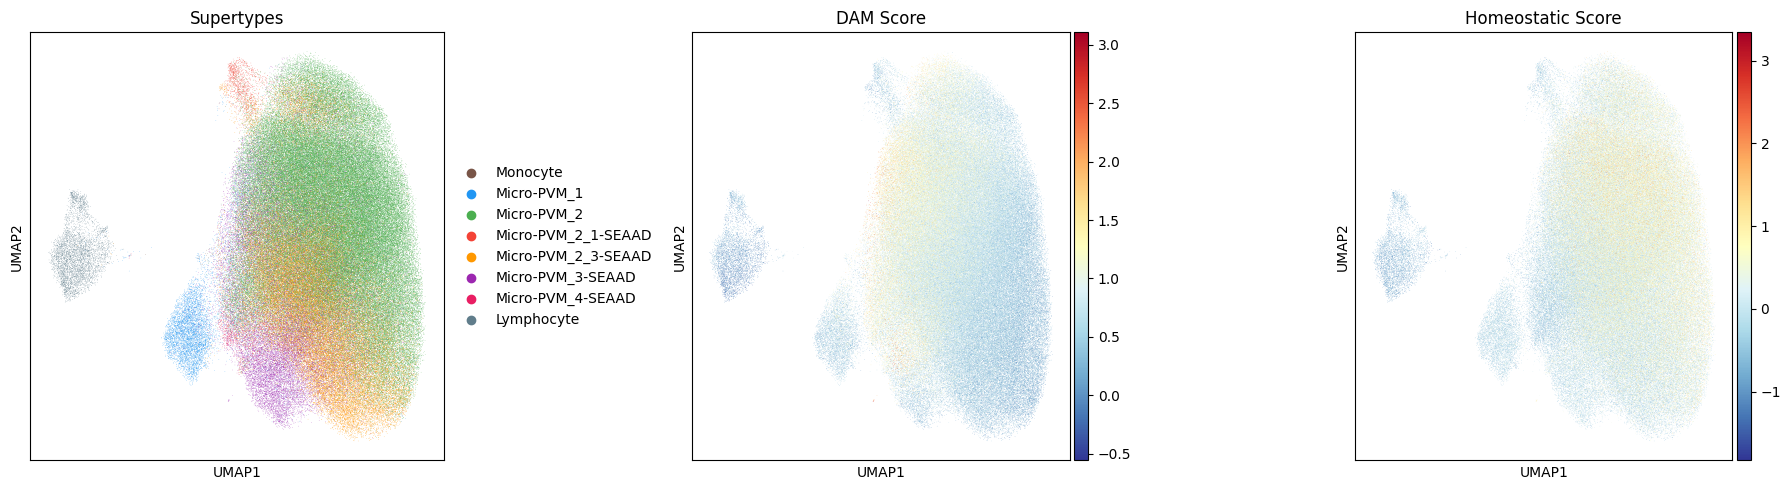

In [35]:
# Cell 8B: compare supertype locations to DAM score zones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(adata, color='Supertype', title='Supertypes', 
           show=False, ax=axes[0])
sc.pl.umap(adata, color='DAM_score', color_map='RdYlBu_r',
           title='DAM Score', show=False, ax=axes[1])
sc.pl.umap(adata, color='Homeostatic_score', color_map='RdYlBu_r',
           title='Homeostatic Score', show=False, ax=axes[2])

plt.tight_layout()
plt.savefig('../results/umap_supertype_vs_scores.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

Supertype activation profile:
          Supertype  DAM_mean  Homeostatic_mean  DAM_Homeostatic_ratio  n_cells
  Micro-PVM_4-SEAAD  1.167405         -0.370321              -3.152417     1767
  Micro-PVM_3-SEAAD  0.819892          0.034230              23.952609    29805
           Monocyte  0.771958         -0.613719              -1.257836       42
        Micro-PVM_2  0.692327          0.273733               2.529204   141248
        Micro-PVM_1  0.626853         -0.307852              -2.036219     7909
Micro-PVM_2_3-SEAAD  0.533373          0.060104               8.874175    53815
Micro-PVM_2_1-SEAAD  0.493061         -0.174362              -2.827802     1458
         Lymphocyte  0.045662         -0.761115              -0.059994     4607

Global mean DAM score: 0.6603

Mann-Whitney U vs global mean per supertype:
Supertype                   DAM mean    p-value  Significant
------------------------------------------------------------
Micro-PVM_4-SEAAD             1.1674   0.00e+00  **

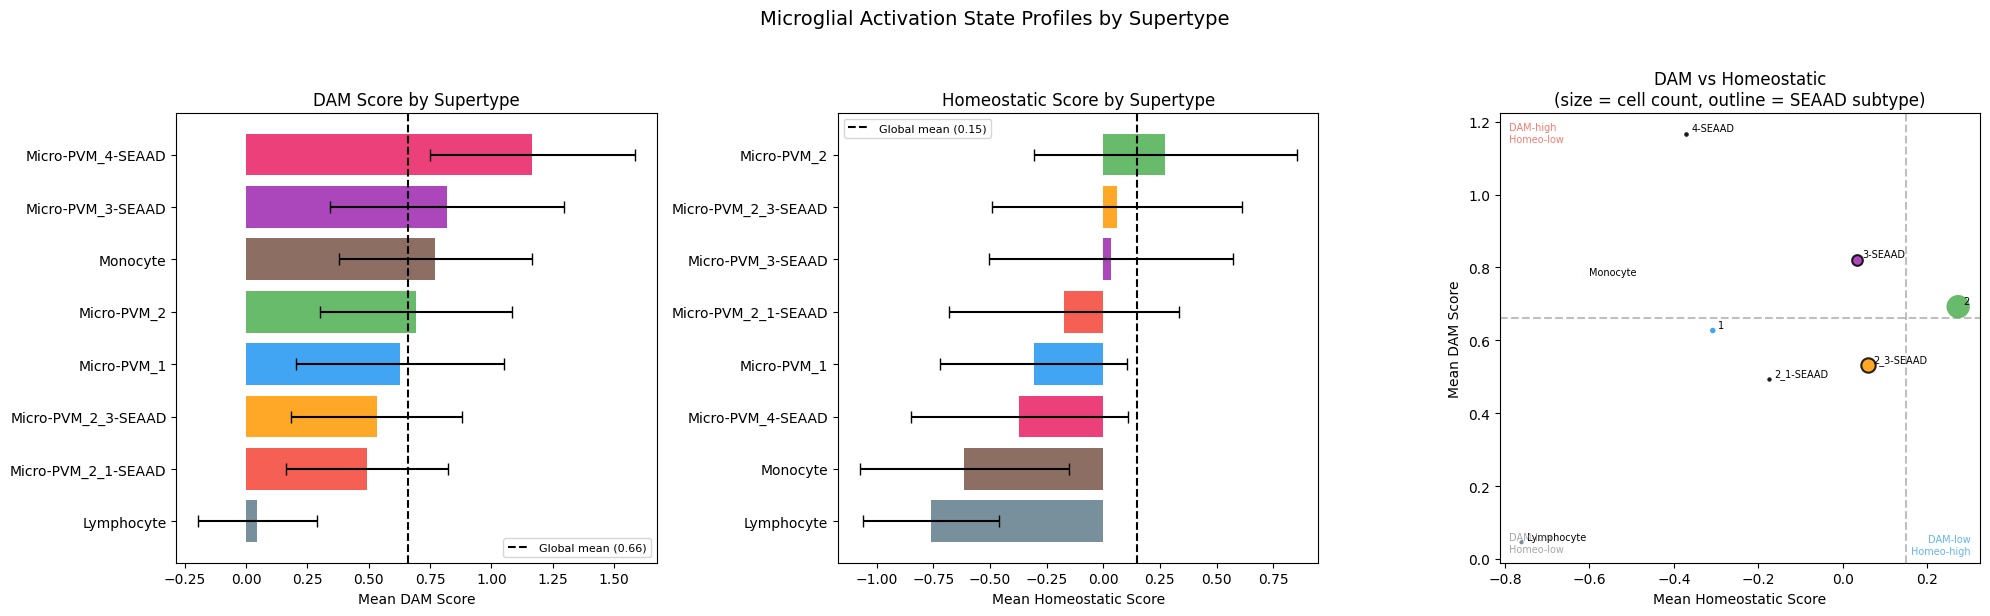


── Activation Pattern Summary ──
Mean DAM score — SEAAD subtypes:     0.7534
Mean DAM score — canonical subtypes: 0.5342

SEAAD vs canonical microglia DAM score: p=1.00e+00
✗ No significant difference detected


In [ ]:
# Cell 8C - Quantify DAM and Homeostatic Score Patterns per Supertype

# 1. Mean scores per supertype 
supertype_scores = adata.obs.groupby('Supertype', observed=True).agg(
    DAM_mean=('DAM_score', 'mean'),
    DAM_std=('DAM_score', 'std'),
    Homeostatic_mean=('Homeostatic_score', 'mean'),
    Homeostatic_std=('Homeostatic_score', 'std'),
    n_cells=('DAM_score', 'count')
).reset_index()

# ratio > 1 means DAM-dominant, < 1 means homeostatic-dominant
supertype_scores['DAM_Homeostatic_ratio'] = (
    supertype_scores['DAM_mean'] / supertype_scores['Homeostatic_mean']
)

# sort by DAM score to show activation spectrum clearly
supertype_scores = supertype_scores.sort_values('DAM_mean', ascending=False)

print("Supertype activation profile:")
print(supertype_scores[['Supertype', 'DAM_mean', 'Homeostatic_mean', 
                          'DAM_Homeostatic_ratio', 'n_cells']].to_string(index=False))

# 2. Statistical test: is each supertype's DAM score significantly 
# different from the global mean?
global_mean = adata.obs['DAM_score'].mean()
print(f"\nGlobal mean DAM score: {global_mean:.4f}")
print(f"\nMann-Whitney U vs global mean per supertype:")
print(f"{'Supertype':<25} {'DAM mean':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 60)

for stype in supertype_scores['Supertype']:
    group = adata.obs[adata.obs['Supertype'] == stype]['DAM_score']
    other = adata.obs[adata.obs['Supertype'] != stype]['DAM_score']
    stat, p = stats.mannwhitneyu(group, other, alternative='two-sided')
    sig = '*** p<0.001' if p < 0.001 else ('* p<0.05' if p < 0.05 else 'ns')
    print(f"{stype:<25} {group.mean():>10.4f} {p:>10.2e} {sig:>12}")

# 3. Figure: dual barplot DAM vs homeostatic per supertype
subtype_colors = {
    'Micro-PVM_1':         '#2196F3',
    'Micro-PVM_2':         '#4CAF50',
    'Micro-PVM_2_1-SEAAD': '#F44336',
    'Micro-PVM_2_3-SEAAD': '#FF9800',
    'Micro-PVM_3-SEAAD':   '#9C27B0',
    'Micro-PVM_4-SEAAD':   '#E91E63',
    'Monocyte':            '#795548',
    'Lymphocyte':          '#607D8B',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# panel 1 — DAM score per supertype
colors = [subtype_colors.get(s, '#333333') 
          for s in supertype_scores['Supertype']]

axes[0].barh(supertype_scores['Supertype'], 
             supertype_scores['DAM_mean'],
             xerr=supertype_scores['DAM_std'],
             color=colors, alpha=0.85, capsize=4)
axes[0].axvline(global_mean, color='black', linestyle='--', 
                linewidth=1.5, label=f'Global mean ({global_mean:.2f})')
axes[0].set_xlabel('Mean DAM Score')
axes[0].set_title('DAM Score by Supertype')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# panel 2 — homeostatic score per supertype
homeo_sorted = supertype_scores.sort_values('Homeostatic_mean', ascending=False)
colors_h = [subtype_colors.get(s, '#333333') 
            for s in homeo_sorted['Supertype']]
global_homeo = adata.obs['Homeostatic_score'].mean()

axes[1].barh(homeo_sorted['Supertype'],
             homeo_sorted['Homeostatic_mean'],
             xerr=homeo_sorted['Homeostatic_std'],
             color=colors_h, alpha=0.85, capsize=4)
axes[1].axvline(global_homeo, color='black', linestyle='--',
                linewidth=1.5, label=f'Global mean ({global_homeo:.2f})')
axes[1].set_xlabel('Mean Homeostatic Score')
axes[1].set_title('Homeostatic Score by Supertype')
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

# panel 3 — scatter: DAM vs homeostatic (one point per supertype)
for _, row in supertype_scores.iterrows():
    color = subtype_colors.get(row['Supertype'], '#333333')
    is_seaad = 'SEAAD' in str(row['Supertype'])
    axes[2].scatter(row['Homeostatic_mean'], row['DAM_mean'],
                    color=color, s=row['n_cells']/500,  # size = cell count
                    alpha=0.85,
                    edgecolors='black' if is_seaad else 'none',
                    linewidth=1.5,
                    zorder=3)
    axes[2].annotate(row['Supertype'].replace('Micro-PVM_', ''),
                     (row['Homeostatic_mean'], row['DAM_mean']),
                     fontsize=7, ha='left',
                     xytext=(4, 2), textcoords='offset points')

# add quadrant lines at global means
axes[2].axhline(global_mean, color='grey', linestyle='--', alpha=0.5)
axes[2].axvline(global_homeo, color='grey', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Mean Homeostatic Score')
axes[2].set_ylabel('Mean DAM Score')
axes[2].set_title('DAM vs Homeostatic\n(size = cell count, outline = SEAAD subtype)')

# quadrant labels
axes[2].text(0.02, 0.98, 'DAM-high\nHomeo-low', transform=axes[2].transAxes,
             fontsize=7, va='top', color='#F44336', alpha=0.7)
axes[2].text(0.98, 0.02, 'DAM-low\nHomeo-high', transform=axes[2].transAxes,
             fontsize=7, ha='right', color='#2196F3', alpha=0.7)
axes[2].text(0.02, 0.02, 'DAM-low\nHomeo-low', transform=axes[2].transAxes,
             fontsize=7, va='bottom', color='grey', alpha=0.7)

plt.suptitle('Microglial Activation State Profiles by Supertype', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/supertype_activation_profiles.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# 4. Print the key biological conclusion
print("\n── Activation Pattern Summary ──")
seaad = supertype_scores[supertype_scores['Supertype'].str.contains('SEAAD')]
canonical = supertype_scores[~supertype_scores['Supertype'].str.contains('SEAAD')]

print(f"Mean DAM score — SEAAD subtypes:     {seaad['DAM_mean'].mean():.4f}")
print(f"Mean DAM score — canonical subtypes: {canonical['DAM_mean'].mean():.4f}")

stat, p = stats.mannwhitneyu(
    adata.obs[adata.obs['Supertype'].str.contains('SEAAD')]['DAM_score'],
    adata.obs[~adata.obs['Supertype'].str.contains('SEAAD') & 
              adata.obs['Supertype'].str.contains('Micro')]['DAM_score'],
    alternative='greater'
)
print(f"\nSEAAD vs canonical microglia DAM score: p={p:.2e}")
print("✓ SEAAD subtypes are significantly DAM-enriched" if p < 0.05 
      else "✗ No significant difference detected")

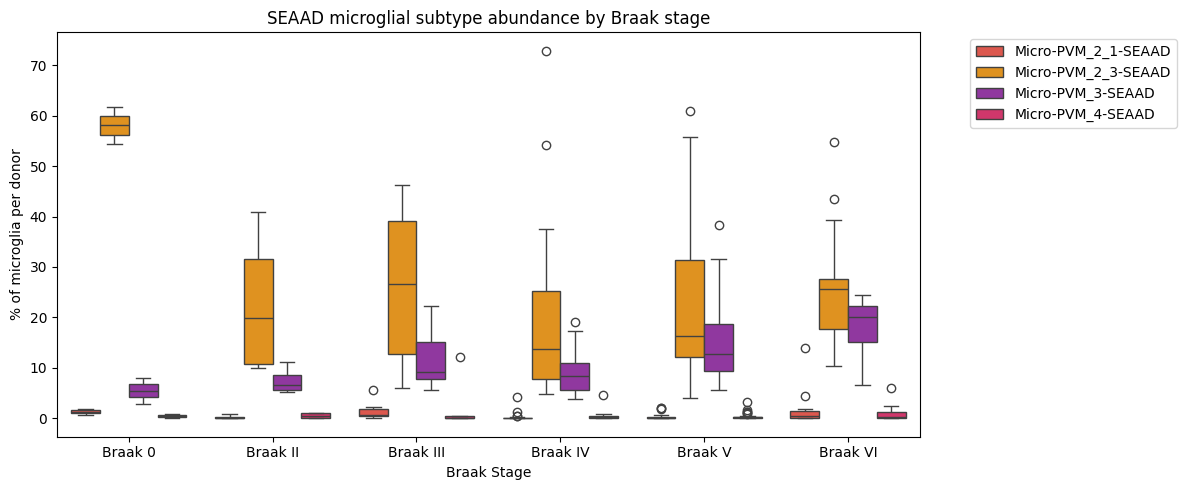

In [36]:
# Cell 9 - Subtype Composition Analysis
# calculate proportion of each supertype per donor
composition = (adata.obs
    .groupby(['Donor ID', 'Supertype'],observed=True)
    .size()
    .unstack(fill_value=0))

composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

# attach braak stage per donor
donor_meta = adata.obs.drop_duplicates('Donor ID').set_index('Donor ID')
composition_pct['Braak'] = donor_meta['Braak']
composition_pct['Cognitive Status'] = donor_meta['Cognitive Status']

# melt for seaborn
comp_melt = composition_pct.reset_index().melt(
    id_vars=['Donor ID', 'Braak', 'Cognitive Status'],
    var_name='Supertype',
    value_name='Proportion'
)

# focus on SEAAD subtypes specifically
seaad_subtypes = [s for s in adata.obs['Supertype'].unique() if 'SEAAD' in str(s)]
comp_seaad = comp_melt[comp_melt['Supertype'].isin(seaad_subtypes)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=comp_seaad, x='Braak', y='Proportion',
            hue='Supertype', ax=ax,
            palette=['#F44336', '#FF9800', '#9C27B0', '#E91E63'])
ax.set_title('SEAAD microglial subtype abundance by Braak stage')
ax.set_ylabel('% of microglia per donor')
ax.set_xlabel('Braak Stage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/composition_braak.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

Number of donors: 84
     Donor ID  DAM_score  Homeostatic_score Braak_num CERAD_num Thal_num  \
0  H19.33.004   0.600702           0.137502         4         0        0   
1  H20.33.001   0.736481           0.154911         4         1        2   
2  H20.33.002   0.650665           0.080936         4         0        0   
3  H20.33.004   0.845696          -0.252823         5         3        5   
4  H20.33.005   0.469378           0.240999         4         2        3   

  ADNC_num CogStatus_num  Age_at_Death  
0        0             0          80.0  
1        1             0          82.0  
2        0             0          97.0  
3        3             1          86.0  
4        2             0          99.0  

Correlation results:
                                        rho       p  significant
Braak Stage                          0.1576  0.1523        False
CERAD Score                          0.1213  0.2717        False
Thal Phase                           0.1121  0.3100        

/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/4081504636.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_df = adata.obs.groupby('Donor ID').agg(


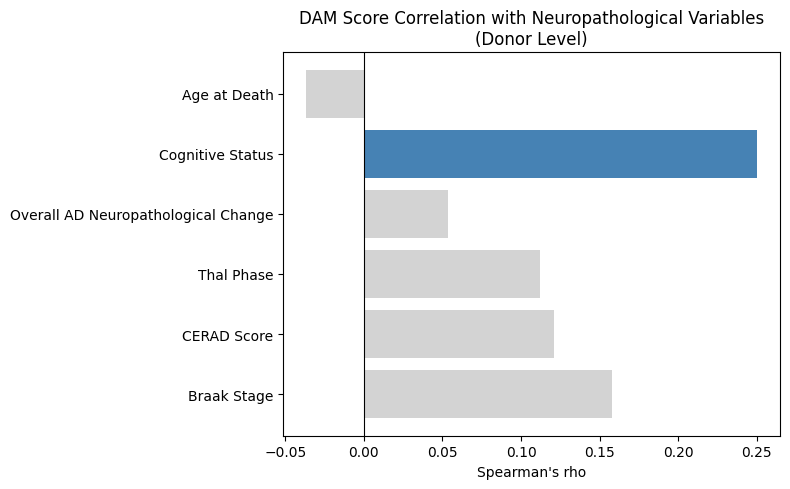

/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/4081504636.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_df['Braak'] = adata.obs.groupby('Donor ID')['Braak'].first().values
/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/4081504636.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='Braak', y='DAM_score', order=braak_order_list,


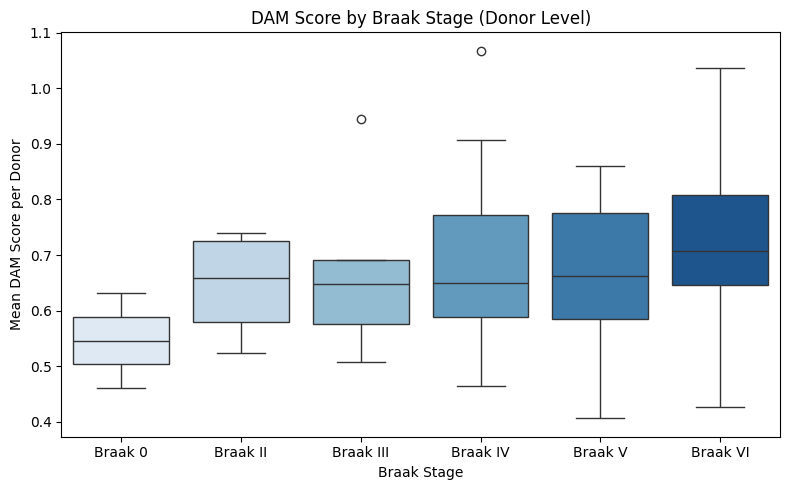

In [45]:
# Cell 10 - Correlation Analysis: DAM score vs Neuropathological Variables (Donor Level)
# Ordinal encoding
braak_order = {'Braak 0': 0, 'Braak II': 2, 'Braak III': 3, 'Braak IV': 4, 'Braak V': 5, 'Braak VI': 6}
cerad_order = {'Absent': 0, 'Sparse': 1, 'Moderate': 2, 'Frequent': 3}
thal_order  = {'Thal 0': 0, 'Thal 1': 1, 'Thal 2': 2, 'Thal 3': 3, 'Thal 4': 4, 'Thal 5': 5}
adnc_order  = {'Not AD': 0, 'Low': 1, 'Intermediate': 2, 'High': 3}
cog_order   = {'No dementia': 0, 'Dementia': 1}

adata.obs['Braak_num']     = adata.obs['Braak'].map(braak_order)
adata.obs['CERAD_num']     = adata.obs['CERAD score'].map(cerad_order)
adata.obs['Thal_num']      = adata.obs['Thal'].map(thal_order)
adata.obs['ADNC_num']      = adata.obs['Overall AD neuropathological Change'].map(adnc_order)
adata.obs['CogStatus_num'] = adata.obs['Cognitive Status'].map(cog_order)

# Aggregate to donor level
donor_df = adata.obs.groupby('Donor ID').agg(
    DAM_score         = ('DAM_score', 'mean'),
    Homeostatic_score = ('Homeostatic_score', 'mean'),
    Braak_num         = ('Braak_num', 'first'),
    CERAD_num         = ('CERAD_num', 'first'),
    Thal_num          = ('Thal_num', 'first'),
    ADNC_num          = ('ADNC_num', 'first'),
    CogStatus_num     = ('CogStatus_num', 'first'),
    Age_at_Death      = ('Age at Death', 'first'),
).reset_index()

print(f"Number of donors: {len(donor_df)}")
print(donor_df.head())

# Spearman correlations
correlations = {}
for col, label in [('Braak_num',     'Braak Stage'),
                   ('CERAD_num',     'CERAD Score'),
                   ('Thal_num',      'Thal Phase'),
                   ('ADNC_num',      'Overall AD Neuropathological Change'),
                   ('CogStatus_num', 'Cognitive Status'),
                   ('Age_at_Death',  'Age at Death')]:
    df_tmp = donor_df[['DAM_score', col]].dropna()
    rho, pval = stats.spearmanr(df_tmp['DAM_score'], df_tmp[col])
    correlations[label] = {'rho': round(rho, 4), 'p': round(pval, 4)}

corr_df = pd.DataFrame(correlations).T
corr_df['significant'] = corr_df['p'] < 0.05
print("\nCorrelation results:")
print(corr_df)

# Plot: correlation bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if s else 'lightgrey' for s in corr_df['significant']]
ax.barh(corr_df.index, corr_df['rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Spearman's rho")
ax.set_title("DAM Score Correlation with Neuropathological Variables\n(Donor Level)")
plt.tight_layout()
plt.savefig('../results/DAM_correlations_donor_level.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Plot: DAM score by Braak stage (boxplot)
donor_df['Braak'] = adata.obs.groupby('Donor ID')['Braak'].first().values
fig, ax = plt.subplots(figsize=(8, 5))
braak_order_list = ['Braak 0', 'Braak II', 'Braak III', 'Braak IV', 'Braak V', 'Braak VI']
sns.boxplot(data=donor_df, x='Braak', y='DAM_score', order=braak_order_list,
            palette='Blues', ax=ax)
ax.set_title('DAM Score by Braak Stage (Donor Level)')
ax.set_xlabel('Braak Stage')
ax.set_ylabel('Mean DAM Score per Donor')
plt.tight_layout()
plt.savefig('../results/DAM_by_Braak_donor_level.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

APOE4 Carriers:     25 donors
APOE4 Non-carriers: 59 donors

DAM_score:
  U = 903.0, p = 0.1065
  Carrier median     = 0.6920 (n=25)
  Non-carrier median = 0.6455 (n=59)

Homeostatic_score:
  U = 675.0, p = 0.5441
  Carrier median     = 0.0842 (n=25)
  Non-carrier median = 0.1519 (n=59)


/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3907028813.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  apoe_map = adata.obs.groupby('Donor ID')['APOE Genotype'].first().reset_index()
/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3907028813.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='APOE4_status', y=score,
/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3907028813.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(d

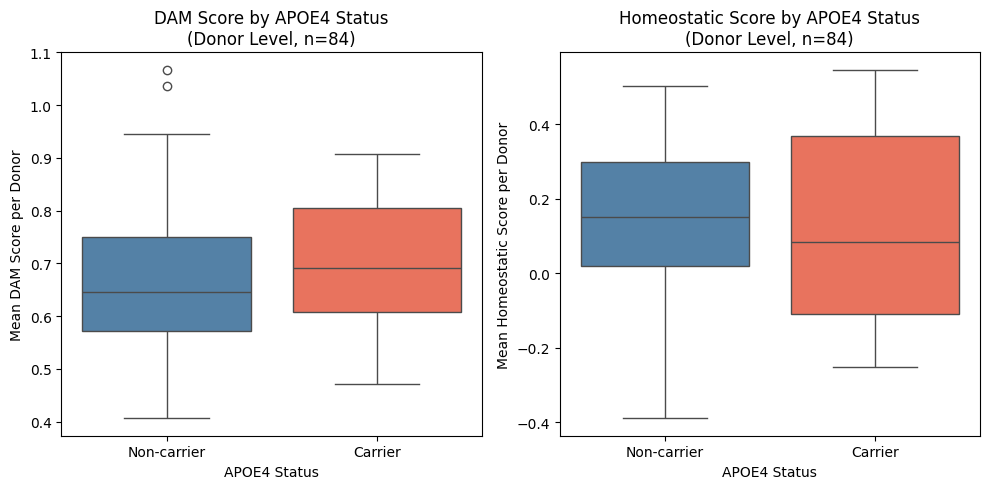

/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3907028813.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='APOE_Genotype', y='DAM_score',


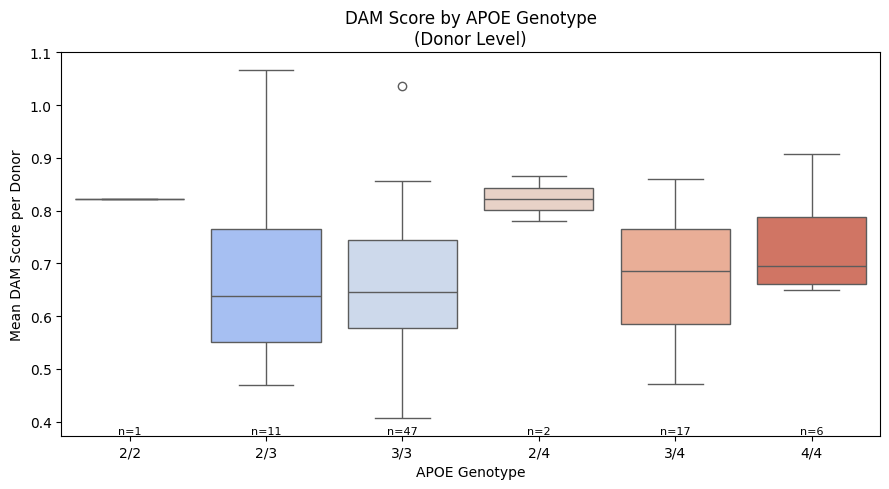

In [ ]:
# Cell 11 - APOE4 Subgroup Analysis: Carriers vs Non-carriers (Donor Level)
from scipy.stats import mannwhitneyu

# Map APOE genotype to donor_df
apoe4_carriers    = ['3/4', '4/4', '2/4']
apoe4_noncarriers = ['3/3', '2/3', '2/2']

apoe_map = adata.obs.groupby('Donor ID')['APOE Genotype'].first().reset_index()
apoe_map.columns = ['Donor ID', 'APOE_Genotype']

# Drop column if it already exists to avoid merge conflicts
if 'APOE_Genotype' in donor_df.columns:
    donor_df = donor_df.drop(columns=['APOE_Genotype'])
if 'APOE4_status' in donor_df.columns:
    donor_df = donor_df.drop(columns=['APOE4_status'])

donor_df = donor_df.merge(apoe_map, on='Donor ID', how='left')

donor_df['APOE4_status'] = donor_df['APOE_Genotype'].apply(
    lambda x: 'Carrier' if x in apoe4_carriers else ('Non-carrier' if x in apoe4_noncarriers else np.nan)
)

print(f"APOE4 Carriers:     {(donor_df['APOE4_status'] == 'Carrier').sum()} donors")
print(f"APOE4 Non-carriers: {(donor_df['APOE4_status'] == 'Non-carrier').sum()} donors")

# Mann-Whitney U test at donor level
for score in ['DAM_score', 'Homeostatic_score']:
    carriers    = donor_df.loc[donor_df['APOE4_status'] == 'Carrier', score].dropna()
    noncarriers = donor_df.loc[donor_df['APOE4_status'] == 'Non-carrier', score].dropna()
    u_stat, pval = mannwhitneyu(carriers, noncarriers, alternative='two-sided')
    print(f"\n{score}:")
    print(f"  U = {u_stat:.1f}, p = {pval:.4f}")
    print(f"  Carrier median     = {carriers.median():.4f} (n={len(carriers)})")
    print(f"  Non-carrier median = {noncarriers.median():.4f} (n={len(noncarriers)})")

# Plot: DAM & Homeostatic scores by APOE4 status
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, score, title in zip(axes,
                             ['DAM_score', 'Homeostatic_score'],
                             ['DAM Score', 'Homeostatic Score']):
    sns.boxplot(data=donor_df, x='APOE4_status', y=score,
                order=['Non-carrier', 'Carrier'],
                palette={'Non-carrier': 'steelblue', 'Carrier': 'tomato'}, ax=ax)
    ax.set_title(f'{title} by APOE4 Status\n(Donor Level, n={len(donor_df.dropna(subset=[score]))})')
    ax.set_xlabel('APOE4 Status')
    ax.set_ylabel(f'Mean {title} per Donor')

plt.tight_layout()
plt.savefig('../results/APOE4_scores_donor_level.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Plot: DAM score by all APOE genotypes
fig, ax = plt.subplots(figsize=(9, 5))
geno_order = ['2/2', '2/3', '3/3', '2/4', '3/4', '4/4']
sns.boxplot(data=donor_df, x='APOE_Genotype', y='DAM_score',
            order=geno_order, palette='coolwarm', ax=ax)
ax.set_title('DAM Score by APOE Genotype\n(Donor Level)')
ax.set_xlabel('APOE Genotype')
ax.set_ylabel('Mean DAM Score per Donor')

# Annotate n per group
for i, geno in enumerate(geno_order):
    n = (donor_df['APOE_Genotype'] == geno).sum()
    ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('../results/DAM_by_APOE_genotype_donor_level.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

DAM-high donors: 42
DAM-low donors:  42

Building pseudobulk matrix...
Pseudobulk matrix shape: (84, 36601)
Running differential expression...

Significantly upregulated genes:   27
Significantly downregulated genes: 22

Top 10 upregulated:
             gene    log2FC  pval_adj
2066       S100A6  0.517698  0.000015
29967   LINC00482  0.736658  0.000025
35605       TIMP1  0.504517  0.000025
34989      LGALS1  0.501388  0.000116
32496  AC020909.2  0.797016  0.000169
18970       CD151  0.586374  0.000243
24426        ARG2  0.548560  0.000369
10526       TGFBI  0.621134  0.000389
17718         VIM  0.514160  0.000473
10816        GPX3  0.547787  0.000473

Top 10 downregulated:
             gene    log2FC  pval_adj
26321  AC009432.2 -1.143987  0.000455
9131   AC098679.6 -0.520433  0.000593
8865    LINC01091 -0.645832  0.000593
30470  AC011139.1 -0.990374  0.001012
6271   AC092053.5 -0.706668  0.001078
20901   LINC02712 -0.717002  0.001209
36062        XACT -0.515406  0.001534
7365   AC10871

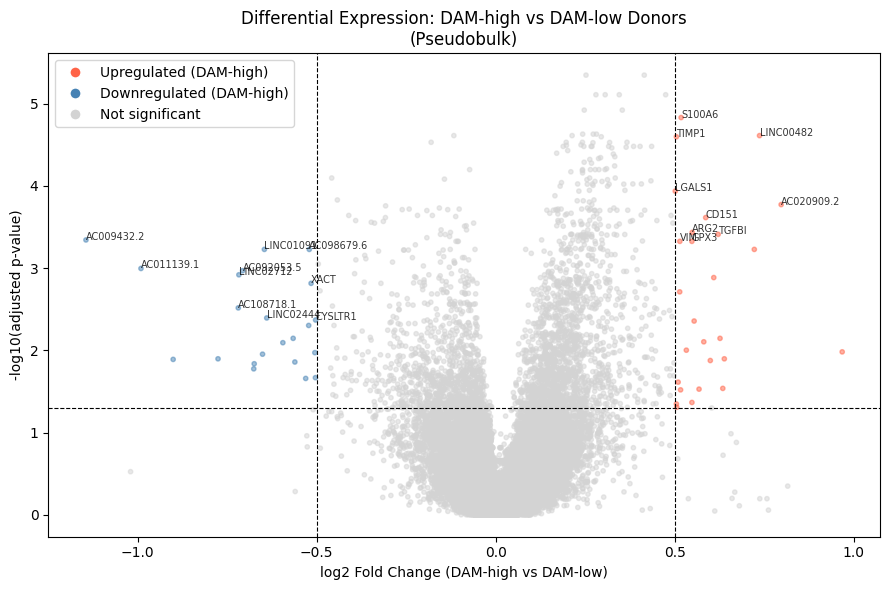

In [ ]:
# Cell 12 - Differential Expression Analysis (Pseudobulk)
from scipy.stats import mannwhitneyu
from scipy.sparse import issparse

# Split donors into DAM-high and DAM-low
dam_median = donor_df['DAM_score'].median()
donor_df['DAM_group'] = donor_df['DAM_score'].apply(
    lambda x: 'DAM-high' if x >= dam_median else 'DAM-low'
)
dam_group_map = donor_df.set_index('Donor ID')['DAM_group'].to_dict()
adata.obs['DAM_group'] = adata.obs['Donor ID'].map(dam_group_map)

print(f"DAM-high donors: {(donor_df['DAM_group'] == 'DAM-high').sum()}")
print(f"DAM-low donors:  {(donor_df['DAM_group'] == 'DAM-low').sum()}")

# Pseudobulk: sum counts per donor
print("\nBuilding pseudobulk matrix...")
donors      = donor_df['Donor ID'].tolist()
gene_names  = adata.var_names.tolist()
pb_matrix   = pd.DataFrame(index=donors, columns=gene_names, dtype=float)

for donor in donors:
    mask = adata.obs['Donor ID'] == donor
    X    = adata[mask].X
    if issparse(X):
        X = X.toarray()
    pb_matrix.loc[donor] = X.sum(axis=0)

print(f"Pseudobulk matrix shape: {pb_matrix.shape}")

# Log-normalize pseudobulk counts
pb_matrix = pb_matrix.div(pb_matrix.sum(axis=1), axis=0) * 1e6  # CPM
pb_matrix = np.log1p(pb_matrix)

# Assign DAM group to pseudobulk matrix
pb_matrix['DAM_group'] = pb_matrix.index.map(dam_group_map)

high_donors = pb_matrix[pb_matrix['DAM_group'] == 'DAM-high'].drop(columns='DAM_group')
low_donors  = pb_matrix[pb_matrix['DAM_group'] == 'DAM-low'].drop(columns='DAM_group')

# Mann-Whitney U per gene
print("Running differential expression...")
results = []
for gene in gene_names:
    u_stat, pval = mannwhitneyu(high_donors[gene], low_donors[gene], alternative='two-sided')
    log2fc = high_donors[gene].mean() - low_donors[gene].mean()
    results.append({'gene': gene, 'log2FC': log2fc, 'pval': pval})

de_results = pd.DataFrame(results)

# Multiple testing correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
_, pval_adj, _, _ = multipletests(de_results['pval'], method='fdr_bh')
de_results['pval_adj'] = pval_adj
de_results = de_results.sort_values('pval_adj')

# Filter significant DEGs
sig_up   = de_results[(de_results['pval_adj'] < 0.05) & (de_results['log2FC'] > 0.5)]
sig_down = de_results[(de_results['pval_adj'] < 0.05) & (de_results['log2FC'] < -0.5)]

print(f"\nSignificantly upregulated genes:   {len(sig_up)}")
print(f"Significantly downregulated genes: {len(sig_down)}")
print("\nTop 10 upregulated:")
print(sig_up.head(10)[['gene', 'log2FC', 'pval_adj']])
print("\nTop 10 downregulated:")
print(sig_down.head(10)[['gene', 'log2FC', 'pval_adj']])

# Check overlap with DAM and homeostatic gene signatures
dam_overlap         = sig_up[sig_up['gene'].str.upper().isin([g.upper() for g in dam_genes])]
homeostatic_overlap = sig_down[sig_down['gene'].str.upper().isin([g.upper() for g in homeostatic_genes])]

print(f"\nDAM signature genes in upregulated:           {dam_overlap['gene'].tolist()}")
print(f"Homeostatic signature genes in downregulated:  {homeostatic_overlap['gene'].tolist()}")

# Volcano plot
fig, ax = plt.subplots(figsize=(9, 6))
de_results['color'] = 'lightgrey'
de_results.loc[(de_results['pval_adj'] < 0.05) & (de_results['log2FC'] >  0.5), 'color'] = 'tomato'
de_results.loc[(de_results['pval_adj'] < 0.05) & (de_results['log2FC'] < -0.5), 'color'] = 'steelblue'
ax.scatter(de_results['log2FC'], -np.log10(de_results['pval_adj'] + 1e-300),
           c=de_results['color'], alpha=0.5, s=10)
label_genes = pd.concat([sig_up.head(10), sig_down.head(10)])
for _, row in label_genes.iterrows():
    ax.annotate(row['gene'],
                xy=(row['log2FC'], -np.log10(row['pval_adj'] + 1e-300)),
                fontsize=7, alpha=0.8)
ax.axvline(x=0.5,  color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=-0.5, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('log2 Fold Change (DAM-high vs DAM-low)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title('Differential Expression: DAM-high vs DAM-low Donors\n(Pseudobulk)')
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='Upregulated (DAM-high)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Downregulated (DAM-high)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey', markersize=8, label='Not significant'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('../figures/fig5_volcano_DE.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [ ]:
# Cell 13 - Saving and Exporting Results
import os
os.makedirs('../results', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Save adata with all scores and annotations
adata.write('../results/adata_scored.h5ad')
print("Saved: ../results/adata_scored.h5ad")

# Save donor-level dataframe
donor_df.to_csv('../results/donor_level_scores.csv', index=False)
print("Saved: ../results/donor_level_scores.csv")

# Save DE results
de_results.to_csv('../results/DE_DAM_high_vs_low.csv', index=False)
sig_up.to_csv('../results/DE_significant_upregulated.csv', index=False)
sig_down.to_csv('../results/DE_significant_downregulated.csv', index=False)
print("Saved: DE results to ../results/")

# Save correlation results
corr_df.to_csv('../results/DAM_correlations_donor_level.csv')
print("Saved: ../results/DAM_correlations_donor_level.csv")

# =============================================
# Save all figures to /figures for GitHub README
# =============================================

# Figure 1: DAM Score Correlation Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if s else 'lightgrey' for s in corr_df['significant']]
ax.barh(corr_df.index, corr_df['rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Spearman's rho")
ax.set_title("DAM Score Correlation with Neuropathological Variables\n(Donor Level, n=84)")
plt.tight_layout()
plt.savefig('../figures/fig1_DAM_correlations.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: ../figures/fig1_DAM_correlations.png")

# Figure 2: DAM Score by Braak Stage
fig, ax = plt.subplots(figsize=(8, 5))
braak_order_list = ['Braak 0', 'Braak II', 'Braak III', 'Braak IV', 'Braak V', 'Braak VI']
sns.boxplot(data=donor_df, x='Braak', y='DAM_score',
            order=braak_order_list, palette='Blues', ax=ax)
ax.set_title('DAM Score by Braak Stage (Donor Level)')
ax.set_xlabel('Braak Stage')
ax.set_ylabel('Mean DAM Score per Donor')
plt.tight_layout()
plt.savefig('../figures/fig2_DAM_by_Braak.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: ../figures/fig2_DAM_by_Braak.png")

# Figure 3: DAM & Homeostatic Score by APOE4 Status
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, score, title in zip(axes,
                             ['DAM_score', 'Homeostatic_score'],
                             ['DAM Score', 'Homeostatic Score']):
    sns.boxplot(data=donor_df, x='APOE4_status', y=score,
                order=['Non-carrier', 'Carrier'],
                palette={'Non-carrier': 'steelblue', 'Carrier': 'tomato'}, ax=ax)
    ax.set_title(f'{title} by APOE4 Status\n(Donor Level, n=84)')
    ax.set_xlabel('APOE4 Status')
    ax.set_ylabel(f'Mean {title} per Donor')
plt.tight_layout()
plt.savefig('../figures/fig3_APOE4_scores.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: ../figures/fig3_APOE4_scores.png")

# Figure 4: DAM Score by APOE Genotype
fig, ax = plt.subplots(figsize=(9, 5))
geno_order = ['2/2', '2/3', '3/3', '2/4', '3/4', '4/4']
sns.boxplot(data=donor_df, x='APOE_Genotype', y='DAM_score',
            order=geno_order, palette='coolwarm', ax=ax)
ax.set_title('DAM Score by APOE Genotype (Donor Level)')
ax.set_xlabel('APOE Genotype')
ax.set_ylabel('Mean DAM Score per Donor')
for i, geno in enumerate(geno_order):
    n = (donor_df['APOE_Genotype'] == geno).sum()
    ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/fig4_DAM_by_APOE_genotype.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: ../figures/fig4_DAM_by_APOE_genotype.png")

# Figure 5: Volcano Plot (saved in Cell 12, just confirm here)
print("Saved: ../figures/fig5_volcano_DE.png (generated in Cell 12)")

# Summary
print("\n========= ANALYSIS SUMMARY =========")
print(f"Total cells:                  {adata.n_obs:,}")
print(f"Total donors:                 {len(donor_df)}")
print(f"DAM genes used:               {len(dam_genes_filtered)}/{len(dam_genes)}")
print(f"Homeostatic genes used:       {len(homeostatic_genes_filtered)}/{len(homeostatic_genes)}")
print(f"\nCorrelations (Spearman rho):")
print(corr_df[['rho', 'p', 'significant']].to_string())
print(f"\nDE Analysis (DAM-high vs DAM-low):")
print(f"  Upregulated genes:            {len(sig_up)}")
print(f"  Downregulated genes:          {len(sig_down)}")
print(f"  DAM signature overlap (up):          {dam_overlap['gene'].tolist()}")
print(f"  Homeostatic signature overlap (down): {homeostatic_overlap['gene'].tolist()}")
print("\nFigures saved to ../figures/")
print("Results saved to ../results/")
print("=====================================")

Saved: ../results/adata_scored.h5ad
Saved: ../results/donor_level_scores.csv
Saved: DE results to ../results/
Saved: ../results/DAM_correlations_donor_level.csv
Saved: ../figures/fig1_DAM_correlations.png


/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3322609166.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='Braak', y='DAM_score',
/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3322609166.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='APOE4_status', y=score,
/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3322609166.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='APOE4_status', y=score,


Saved: ../figures/fig2_DAM_by_Braak.png
Saved: ../figures/fig3_APOE4_scores.png
Saved: ../figures/fig4_DAM_by_APOE_genotype.png
Saved: ../figures/fig5_volcano_DE.png (generated in Cell 12)

========= ANALYSIS SUMMARY =========
Total cells:                  240,651
Total donors:                 84
DAM genes used:               26/30
Homeostatic genes used:       8/11

Correlations (Spearman rho):
                                        rho       p  significant
Braak Stage                          0.1576  0.1523        False
CERAD Score                          0.1213  0.2717        False
Thal Phase                           0.1121  0.3100        False
Overall AD Neuropathological Change  0.0536  0.6280        False
Cognitive Status                     0.2504  0.0216         True
Age at Death                        -0.0369  0.7388        False

DE Analysis (DAM-high vs DAM-low):
  Upregulated genes:            27
  Downregulated genes:          22
  DAM signature overlap (up):          [

/var/folders/lr/fg_k2_f92yngzjqwcldtg8d40000gn/T/ipykernel_2966/3322609166.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=donor_df, x='APOE_Genotype', y='DAM_score',
